<a href="https://colab.research.google.com/github/Nikhil5566/EDA-Repo/blob/main/GPUs_Specs_From_1986_to_2026_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GPUs Specs From 1986 to 2026 Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
import warnings
warnings.filterwarnings('ignore')

# About the dataset

This dataset, titled "GPUs Specs From 1986 to 2026," provides a comprehensive collection of graphics processing unit specifications, covering a wide historical and projected timeline. It contains 3203 entries and 134 columns detailing various aspects of GPUs, from basic identification like Brand and Name to intricate technical specifications such as Graphics Processor, Memory Size and Type, Bus Width, Release Date, Architecture, Process Size, and Memory Clock. Initial exploration revealed a significant number of missing values across many columns, particularly in advanced performance metrics, which were subsequently handled by imputing with the mode for categorical data and mean for numerical data (though in our df_selected all selected features were handled as categorical for mode imputation where missing values existed).

The univariate analysis highlighted key trends: NVIDIA, AMD, and ATI are the most represented brands. Common memory types include GDDR5, GDDR3, and system-shared memory, while 128-bit and 64-bit bus widths are prevalent. The dataset also showcases a technological evolution, with many GPUs fabricated using 28 nm and 40 nm processes, and architectural styles like TeraScale 2 and GCN 1.0 being frequently observed. Overall, the dataset offers a rich resource for understanding the historical development and future trends of GPU technology.

In [2]:
# Installing Kaggle API
!pip install -q kaggle

# Uploading kaggle.json
from google.colab import files
files.upload()

# Moving kaggle.json to ~/.kaggle/
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Downloading the dataset using Kaggle API
!kaggle datasets download -d ellimaaac/gpus-specs-from-1986-to-2026

# Unziping the downloaded file
!unzip gpus-specs-from-1986-to-2026.zip

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/ellimaaac/gpus-specs-from-1986-to-2026
License(s): CC0-1.0
  0% 0.00/213k [00:00<?, ?B/s]
100% 213k/213k [00:00<00:00, 579MB/s]
Archive:  gpus-specs-from-1986-to-2026.zip
  inflating: gpu_1986-2026.csv       


In [3]:
df = pd.read_csv('gpu_1986-2026.csv')
df.head(11)

,Brand,Name,Top__GRAPHICS PROCESSOR,Top__PIXEL SHADERS,Top__VERTEX SHADERS,Top__TMUS,Top__ROPS,Top__MEMORY SIZE,Top__MEMORY TYPE,Top__BUS WIDTH,...,Render Config__SMX Count,Mobile Graphics__Launch Price,Render Config__SMM Count,Render Config__Tensor Cores,Theoretical Performance__BF16,Theoretical Performance__TF32,Theoretical Performance__FP64 Tensor,Graphics Features__NVENC,Graphics Features__NVDEC,Mobile Graphics__Announced
0,ATI,Color Emulation Card,CW16800-A,NaN,NaN,NaN,NaN,32 KB,DRAM,32 bit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ATI,Graphics Solution,CW16800-A,NaN,NaN,NaN,NaN,64 KB,DRAM,32 bit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,ATI,EGA Wonder 800,16899-0,1,NaN,NaN,1,256 KB,DRAM,32 bit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,ATI,Graphics Solution Plus,CW16800-B,NaN,NaN,NaN,NaN,64 KB,DRAM,32 bit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ATI,VGA Improved Performance,16899-0,1,NaN,NaN,1,256 KB,DRAM,32 bit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,ATI,EGA Wonder 480,16899-0,1,NaN,NaN,1,256 KB,DRAM,32 bit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,ATI,EGA Wonder 800+,18800-1,1,NaN,NaN,1,256 KB,DRAM,32 bit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,ATI,VGA Wonder,18800-1,1,NaN,NaN,1,256 KB,DRAM,32 bit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,ATI,VGA Wonder+,28800-5,1,NaN,NaN,1,512 KB,DRAM,32 bit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,ATI,8514-Ultra,Mach8,1,NaN,NaN,1,1 MB,VRAM,32 bit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df.tail(11)

,Brand,Name,Top__GRAPHICS PROCESSOR,Top__PIXEL SHADERS,Top__VERTEX SHADERS,Top__TMUS,Top__ROPS,Top__MEMORY SIZE,Top__MEMORY TYPE,Top__BUS WIDTH,...,Render Config__SMX Count,Mobile Graphics__Launch Price,Render Config__SMM Count,Render Config__Tensor Cores,Theoretical Performance__BF16,Theoretical Performance__TF32,Theoretical Performance__FP64 Tensor,Graphics Features__NVENC,Graphics Features__NVDEC,Mobile Graphics__Announced
3192,XGI,Volari Duo V8 Ultra,XG40 x2,4 x2,2 x2,8 x2,4 x2,256 MB x2,DDR,256 bit x2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3193,XGI,Volari V3,XG42,2,1,4,2,128 MB,DDR,128 bit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3194,XGI,Volari V3 XT,XG42,2,1,4,2,128 MB,DDR,128 bit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3195,XGI,Volari V5,XG41,2,2,4,2,256 MB,DDR2,128 bit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3196,XGI,Volari V5,XG41,2,2,4,2,256 MB,DDR,128 bit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3197,XGI,Volari V5 Ultra,XG41,2,2,4,2,256 MB,DDR,128 bit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3198,XGI,Volari V5 Ultra,XG41,2,2,4,2,256 MB,DDR2,128 bit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3199,XGI,Volari V8,XG40,4,2,8,4,256 MB,DDR,128 bit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3200,XGI,Volari V8,XG40,4,2,8,4,256 MB,DDR2,128 bit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3201,XGI,Volari V8 Ultra,XG40,4,2,8,4,256 MB,DDR2,128 bit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
df.shape

(3203, 134)

In [6]:
df.columns

Index(['Brand', 'Name', 'Top__GRAPHICS PROCESSOR', 'Top__PIXEL SHADERS',
       'Top__VERTEX SHADERS', 'Top__TMUS', 'Top__ROPS', 'Top__MEMORY SIZE',
       'Top__MEMORY TYPE', 'Top__BUS WIDTH',
       ...
       'Render Config__SMX Count', 'Mobile Graphics__Launch Price',
       'Render Config__SMM Count', 'Render Config__Tensor Cores',
       'Theoretical Performance__BF16', 'Theoretical Performance__TF32',
       'Theoretical Performance__FP64 Tensor', 'Graphics Features__NVENC',
       'Graphics Features__NVDEC', 'Mobile Graphics__Announced'],
      dtype='object', length=134)

In [7]:
df.dtypes

,0
Brand,object
Name,object
Top__GRAPHICS PROCESSOR,object
Top__PIXEL SHADERS,object
Top__VERTEX SHADERS,object
...,...
Theoretical Performance__TF32,object
Theoretical Performance__FP64 Tensor,object
Graphics Features__NVENC,object
Graphics Features__NVDEC,object


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3203 entries, 0 to 3202
Columns: 134 entries, Brand to Mobile Graphics__Announced
dtypes: float64(16), int64(2), object(116)
memory usage: 3.3+ MB


In [9]:
df.describe(include = 'all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Brand,3203,11,NVIDIA,1436,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Name,3203,2874,ION,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Top__GRAPHICS PROCESSOR,3203,603,GK107,44,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Top__PIXEL SHADERS,828,20,4,293,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Top__VERTEX SHADERS,629,19,2,190,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
Theoretical Performance__TF32,7,1,155.92 TFLOPs (8:1),7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Theoretical Performance__FP64 Tensor,7,1,19.49 TFLOPS (1:1),7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Graphics Features__NVENC,1,1,1x 7th Gen,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Graphics Features__NVDEC,1,1,2x 5th Gen,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
df.isnull().sum()

,0
Brand,0
Name,0
Top__GRAPHICS PROCESSOR,0
Top__PIXEL SHADERS,2375
Top__VERTEX SHADERS,2574
...,...
Theoretical Performance__TF32,3196
Theoretical Performance__FP64 Tensor,3196
Graphics Features__NVENC,3202
Graphics Features__NVDEC,3202


In [11]:
df.duplicated().sum()

np.int64(3)

In [15]:
selected_columns = [
    'Brand',
    'Name',
    'Top__GRAPHICS PROCESSOR',
    'Top__MEMORY SIZE',
    'Top__MEMORY TYPE',
    'Top__BUS WIDTH',
    'Graphics Card__Release Date',
    'Graphics Processor__Architecture',
    'Graphics Processor__Process Size',
    'Clock Speeds__Memory Clock'
]

df_selected = df[selected_columns].copy()
display(df_selected.head())

,Brand,Name,Top__GRAPHICS PROCESSOR,Top__MEMORY SIZE,Top__MEMORY TYPE,Top__BUS WIDTH,Graphics Card__Release Date,Graphics Processor__Architecture,Graphics Processor__Process Size,Clock Speeds__Memory Clock
0,ATI,Color Emulation Card,CW16800-A,32 KB,DRAM,32 bit,"Aug 4th, 1986",Wonder,800 nm,5 MHz
1,ATI,Graphics Solution,CW16800-A,64 KB,DRAM,32 bit,"Sep 22nd, 1986",Wonder,800 nm,5 MHz
2,ATI,EGA Wonder 800,16899-0,256 KB,DRAM,32 bit,"Nov 16th, 1987",Wonder,800 nm,8 MHz
3,ATI,Graphics Solution Plus,CW16800-B,64 KB,DRAM,32 bit,"Mar 23rd, 1987",Wonder,800 nm,5 MHz
4,ATI,VGA Improved Performance,16899-0,256 KB,DRAM,32 bit,"Sep 28th, 1987",Wonder,800 nm,10 MHz


In [17]:
df_selected.isnull().sum()

,0
Brand,0
Name,0
Top__GRAPHICS PROCESSOR,0
Top__MEMORY SIZE,0
Top__MEMORY TYPE,0
Top__BUS WIDTH,0
Graphics Card__Release Date,1458
Graphics Processor__Architecture,25
Graphics Processor__Process Size,0
Clock Speeds__Memory Clock,0


In [19]:
# Identifying numerical and categorical columns
numerical_cols = df_selected.select_dtypes(include=np.number).columns
categorical_cols = df_selected.select_dtypes(include='object').columns

# For numerical columns, we might impute with the mean or median
for col in numerical_cols:
    if df_selected[col].isnull().any():
        df_selected[col].fillna(df_selected[col].mean(), inplace=True)

# For categorical columns, we might impute with the mode or a constant
for col in categorical_cols:
    if df_selected[col].isnull().any():
        df_selected[col].fillna(df_selected[col].mode()[0], inplace=True)

print("\nMissing values after handling:")
df_selected.isnull().sum()


Missing values after handling:


,0
Brand,0
Name,0
Top__GRAPHICS PROCESSOR,0
Top__MEMORY SIZE,0
Top__MEMORY TYPE,0
Top__BUS WIDTH,0
Graphics Card__Release Date,0
Graphics Processor__Architecture,0
Graphics Processor__Process Size,0
Clock Speeds__Memory Clock,0


# Univariate Analysis

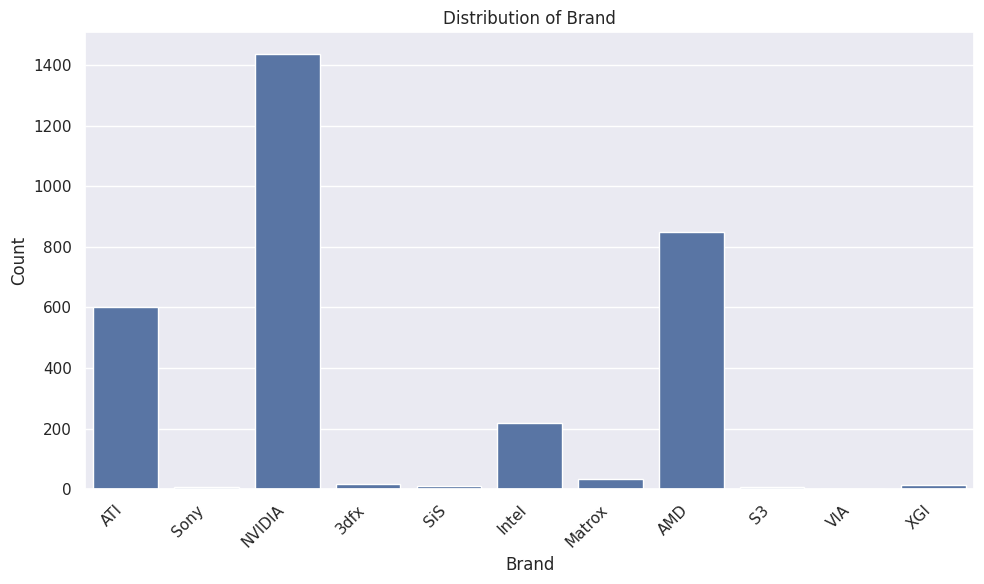

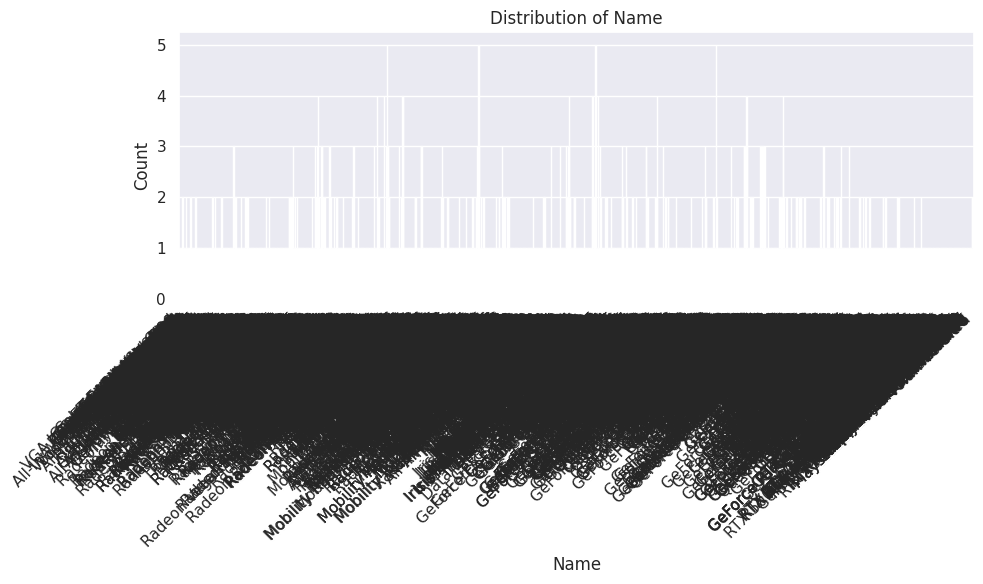

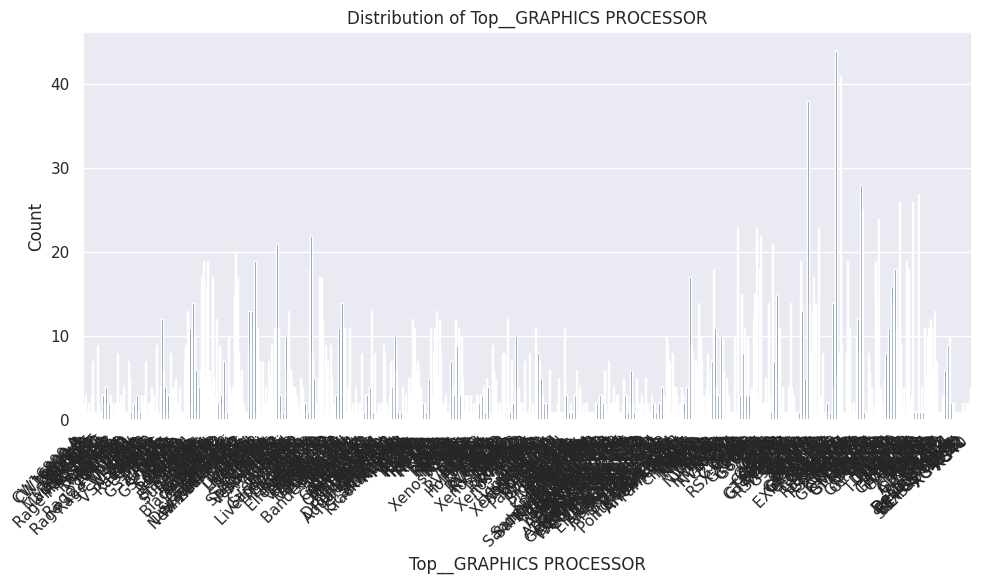

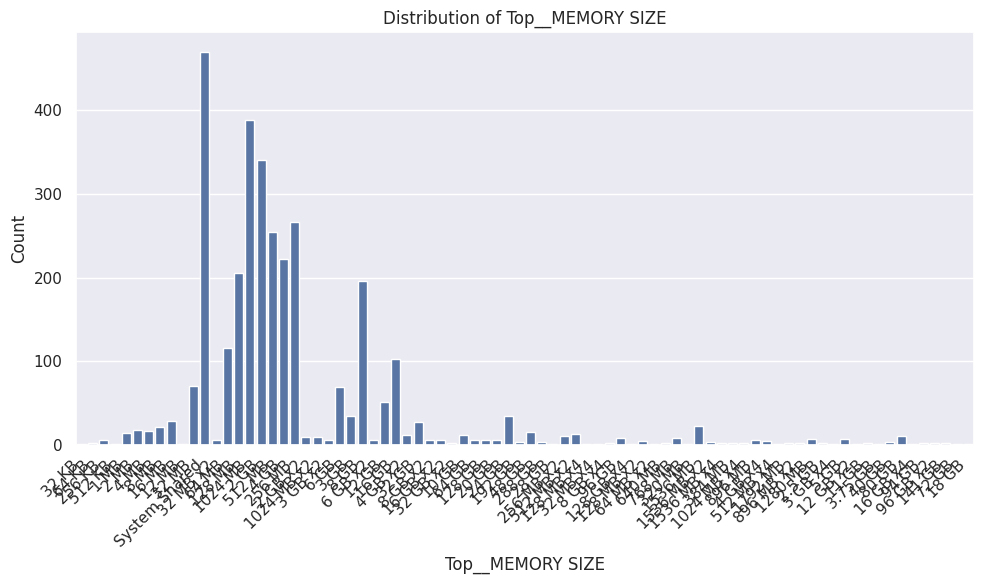

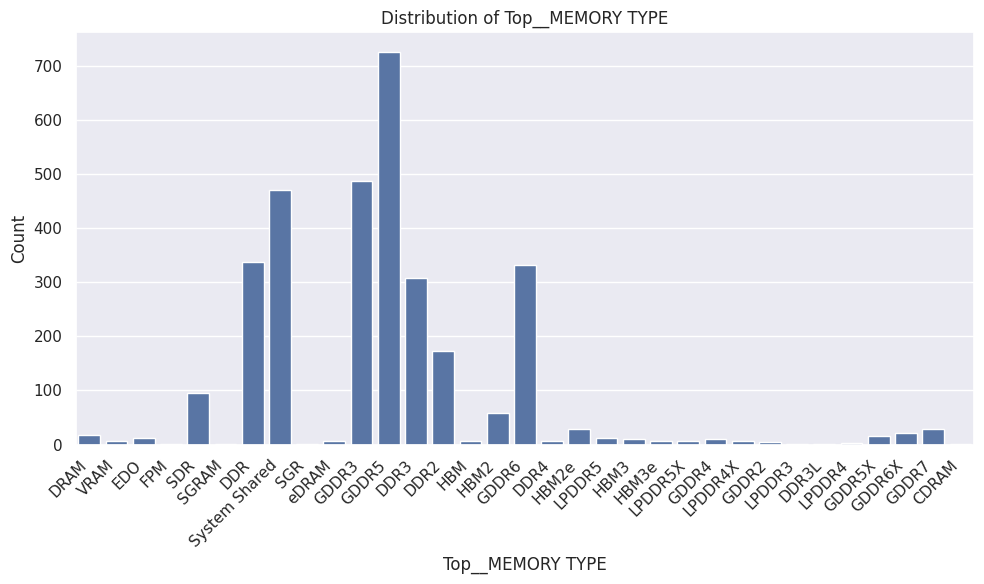

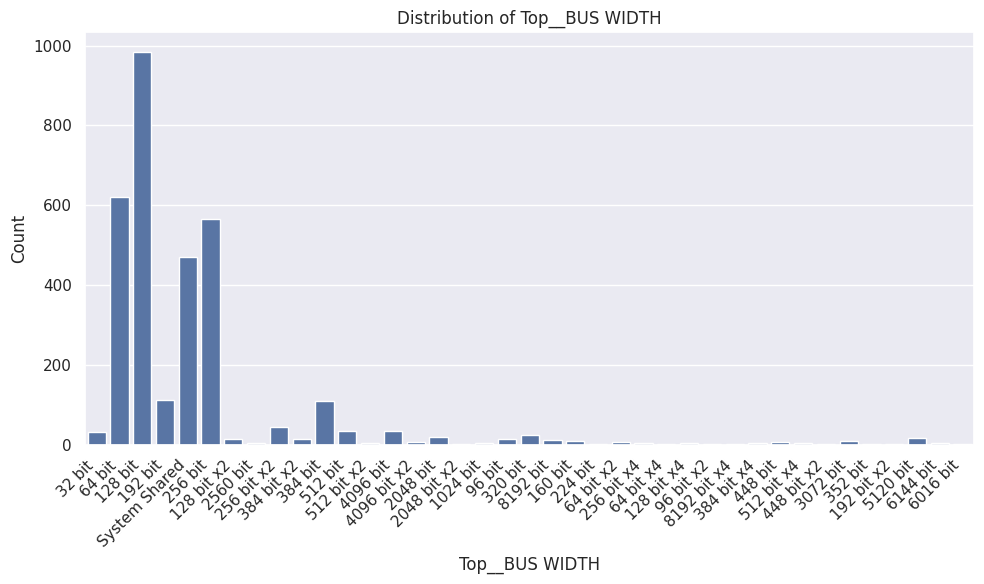

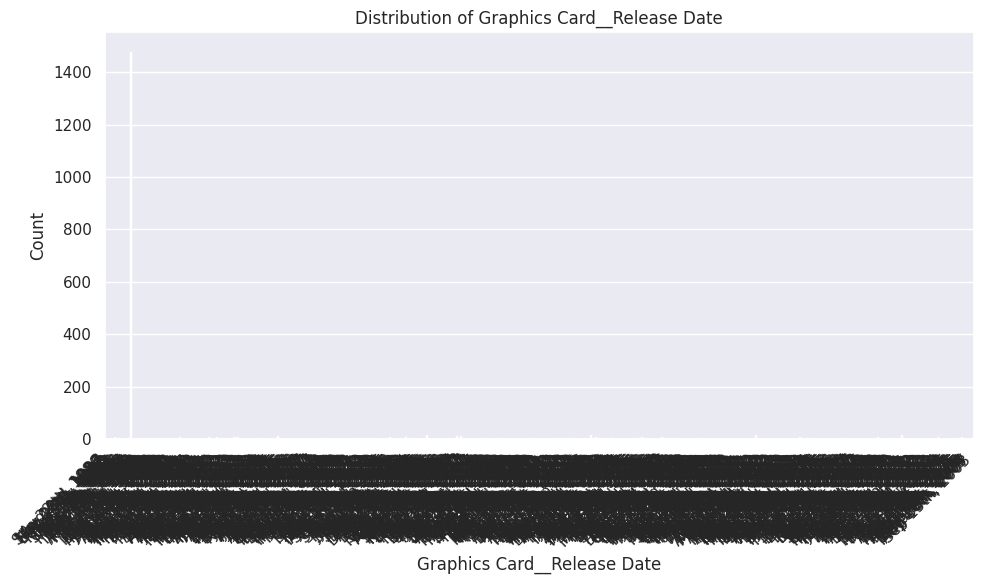

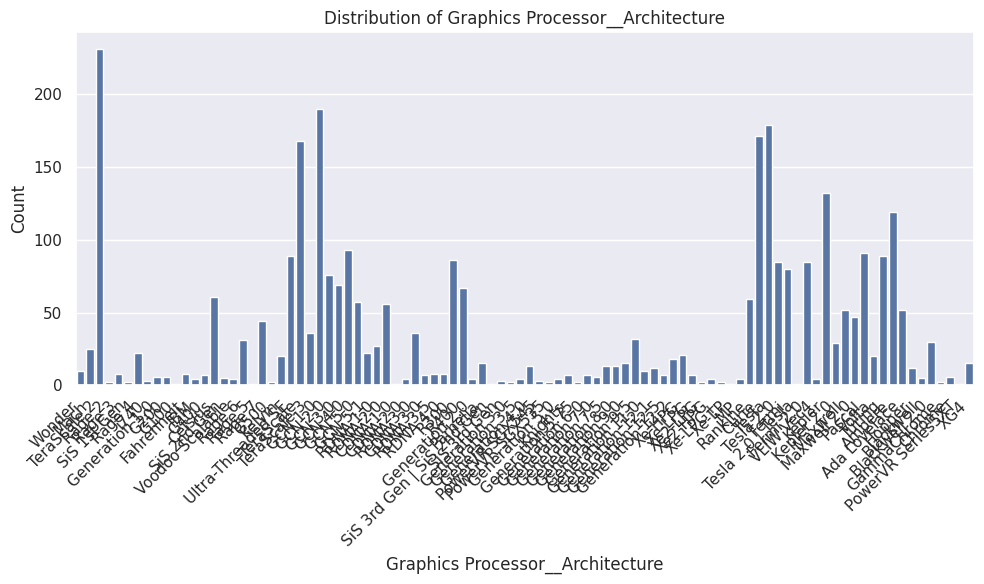

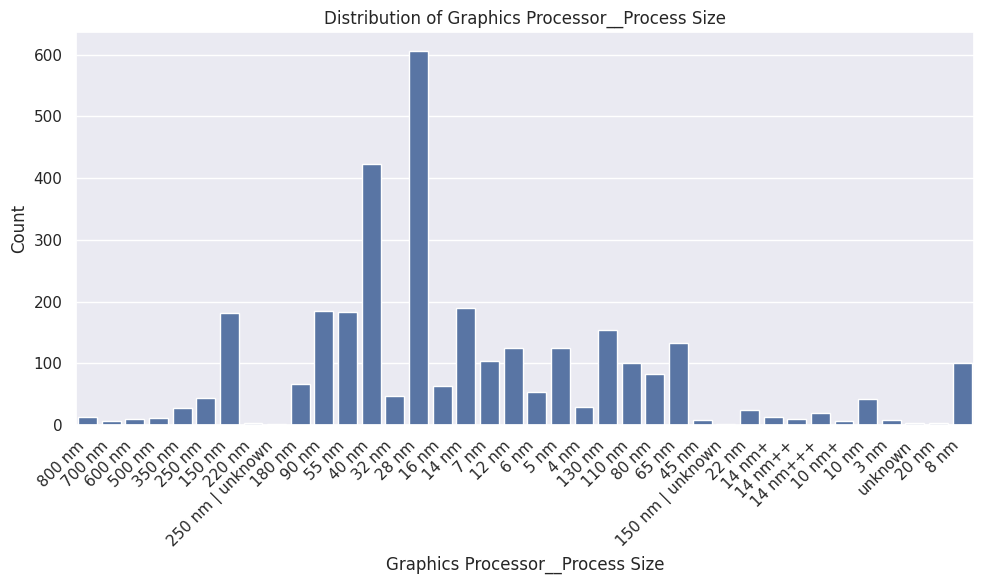

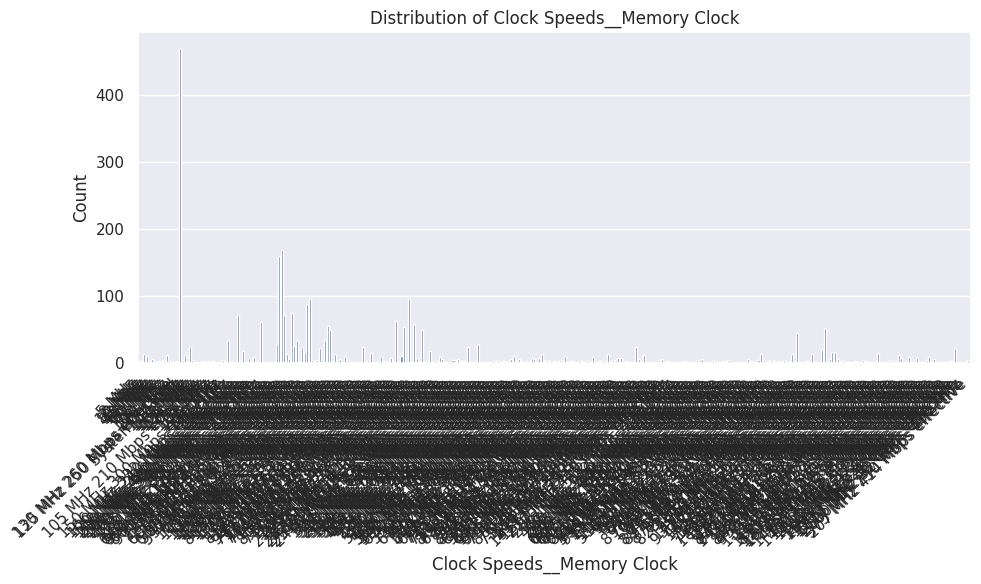

Value counts for Brand:
Brand
NVIDIA    1436
AMD        850
ATI        603
Intel      220
Matrox      35
3dfx        16
XGI         15
SiS         11
Sony         9
S3           6
VIA          2
Name: count, dtype: int64

Value counts for Name:
Name
ION                            5
Radeon Vega 3 Embedded         5
UHD Graphics 24EU Mobile       5
Radeon Xpress 200M IGP         5
GeForce 6800 XT                4
                              ..
Mobility Radeon X600 SE        1
Mobility Radeon X800           1
Radeon 7000 Mac Edition        1
Radeon 7000 Mac Edition PCI    1
Mobility Radeon 9600           1
Name: count, Length: 2874, dtype: int64

Value counts for Top__GRAPHICS PROCESSOR:
Top__GRAPHICS PROCESSOR
GK107         44
GK104         41
GF108         38
GM107         28
GA107         27
              ..
TU117SB        1
GA107SB        1
SST1           1
EE+GS-65nm     1
TU106 x2       1
Name: count, Length: 603, dtype: int64

Value counts for Top__MEMORY SIZE:
Top__MEMORY SIZE
S

In [21]:
# Getting a list of numerical columns
numerical_cols = df_selected.select_dtypes(include=np.number).columns.tolist()

# Iterating through numerical columns and create histograms
for col in numerical_cols:
    plt.figure(figsize=(10, 6))
    sns.histplot(data=df_selected, x=col, kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

# Getting a list of categorical columns
categorical_cols = df_selected.select_dtypes(include='object').columns.tolist()

# Iterate through categorical columns and create countplots
for col in categorical_cols:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df_selected, x=col)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# We can also use value_counts for a quick look at categorical data distribution
for col in categorical_cols:
    print(f"Value counts for {col}:\n{df_selected[col].value_counts()}\n")

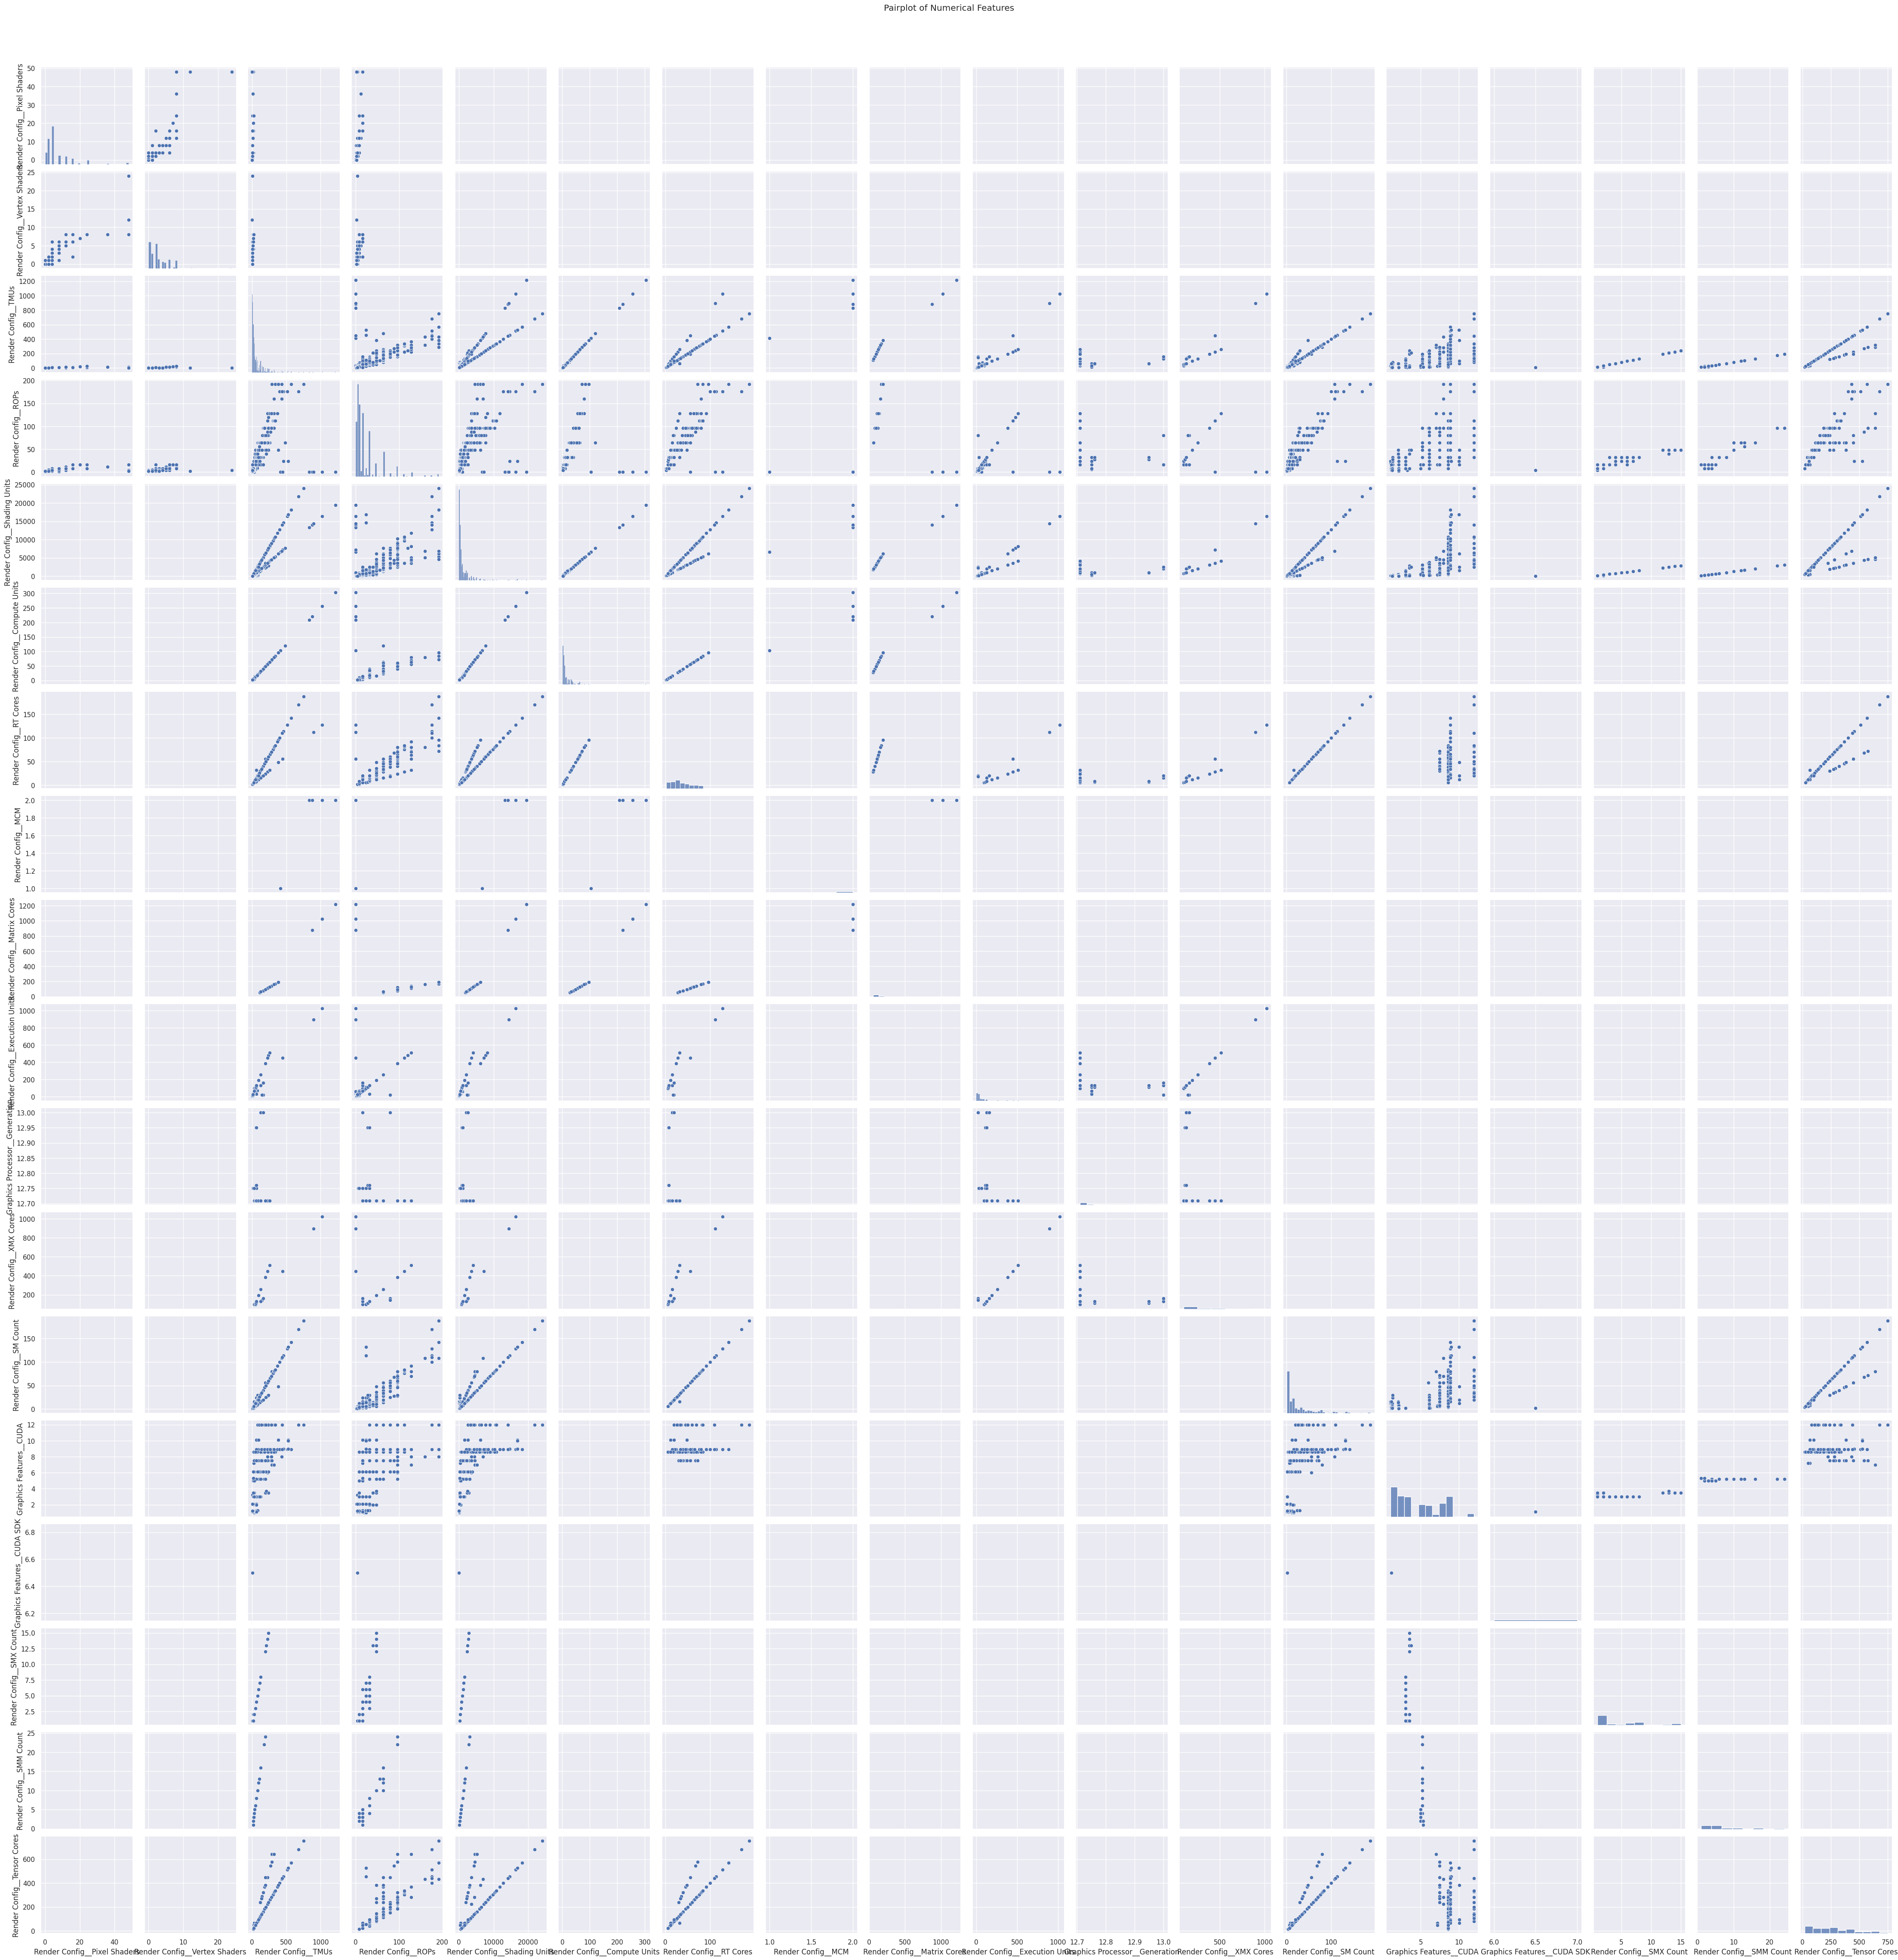

In [23]:
sns.pairplot(df.select_dtypes(include=np.number))
plt.suptitle('Pairplot of Numerical Features', y=1.02)
plt.show()

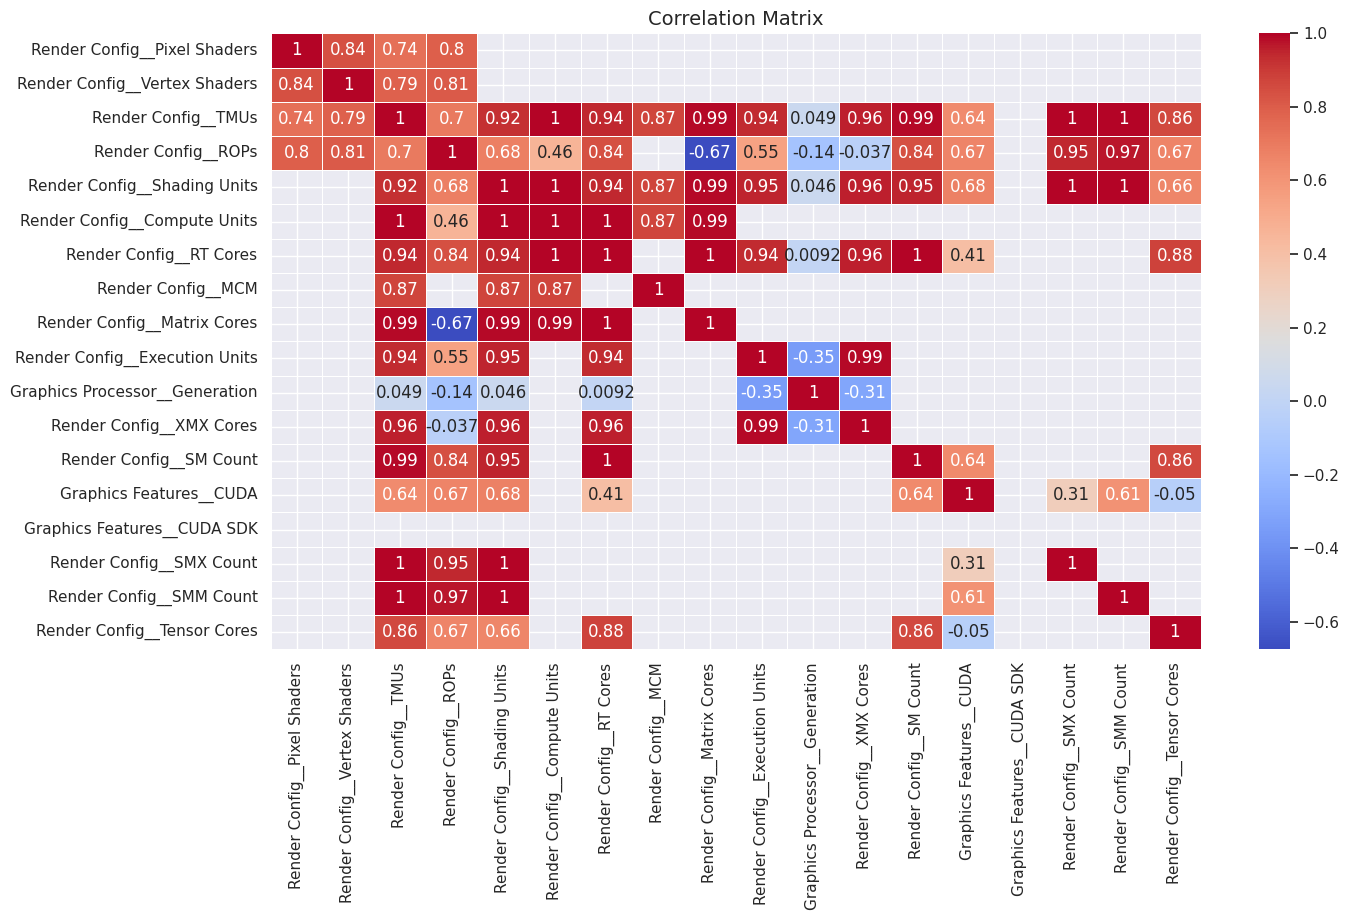

In [24]:
plt.figure(figsize=(15, 8))
sns.heatmap(df.corr(numeric_only = True), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix", fontsize=14)
plt.show()

# Thank You